In [1]:
import numpy as np
import matplotlib.pyplot as plt

def grad_F_cube(x):
    # clip for numerical stability
    x_clipped = np.clip(x, -0.999999, 0.999999)
    return np.arctanh(x_clipped)           # element‑wise atanh


def grad_F_inv_cube(u):
    return np.tanh(u)                      # element‑wise tanh
    
def generate_loss_sequence_bias(d, s, T, rng, mean_radius=0.8):
    """
    Returns
    -------
    losses : ndarray, shape (T, d)   (each row is s‑sparse, ‖·‖₂ ≤ 1)
    
    If you also want the mean vector μ and the support, call
        losses, mu, support = generate_loss_sequence_bias(..., return_details=True)
    """
    # ---------- support ----------
    support = rng.choice(d, size=s, replace=False)

    # ---------- mean μ on that support ----------
    direction = rng.normal(size=s)
    direction /= np.linalg.norm(direction, 1)
    mu = np.zeros(d)
    mu[support] = mean_radius * direction        # ‖μ‖₂ = mean_radius < 1

    # ---------- build loss matrix ----------
    losses = np.zeros((T, d))
    for t in range(T):
        z = np.zeros(d)
        for idx in support:
            p_plus = 0.5 * (1.0 + mu[idx])       # Rademacher(μ_i)
            z[idx] = 1.0 if rng.random() < p_plus else -1.0
        norm_z = np.linalg.norm(z)
        if norm_z > 1.0:                         # project to unit ball
            z /= norm_z
        losses[t, :] = z                         # 1‑D row stored as (d,)

    return losses          # <‑‑ ONLY the (T,d) array

In [2]:
################################# Alg ################################################

# OSMD on the hypercube (Section 4, Theorem 5) 
def run_osmd_hypercube(d, T, losses, seed=None):
    rng   = np.random.default_rng(seed)
    eta   = np.sqrt(np.log(2.0) / (3.0 * T))                 # learning‑rate
    gamma = min(1.0, 2.0 * d * eta)                          # exploration prob.

    a          = np.zeros(d)                                 # a₁ = argmin F
    g_cum      = np.zeros(d)                                 # Σ z̃ₛ
    actions    = np.zeros((T, d))                            # played ãₜ
    estimates  = np.zeros((T, d))                            # z̃ₜ
    I          = np.eye(d)
    
    z_sum      = np.zeros(d)  
    loss_hist   = np.zeros(T)
    z_norm_hist = np.zeros(T)
    
    for t in range(T):
        # --- (a) perturb & play
        if rng.random() < gamma:
            idx   = rng.integers(d)
            a_tld = np.zeros(d)
            a_tld[idx] = rng.choice([-1.0, 1.0])
        else:
            probs = 0.5 * (1.0 + a)                          # (1+aᵢ)/2
            a_tld = 2.0 * (rng.random(d) < probs).astype(float) - 1.0

        # bandit loss
        l_scalar = float(a_tld @ losses[t])

        # second‑moment matrix Pₜ (Eq. right before (5)) 
        P = (gamma / d) * I + (1.0 - gamma) * (np.outer(a, a) + np.diag(1.0 - a**2))

        # --- (b) unbiased loss estimate
        z_hat = np.linalg.solve(P, a_tld) * l_scalar

        # --- (c) mirror step: a_{t+1} = tanh(−η Σ z̃)
        g_cum += z_hat
        a      = grad_F_inv_cube(-eta * g_cum)

        # log
        actions[t]   = a_tld
        estimates[t] = z_hat

        
        loss_hist[t]   = l_scalar
        z_sum          += losses[t]
        a_star         = np.sign(z_sum)      # best fixed action
        z_norm_hist[t] = -np.dot(a_star, z_sum)

    cumulative_loss = np.cumsum(loss_hist)
    regret          = cumulative_loss - z_norm_hist
    return regret

In [3]:
def run_osmd_hypercube_selective(d, T, s, losses, seed=None):
    rng   = np.random.default_rng(seed)
    eta   = 1.0 / np.sqrt(T)                     # learning‑rate η = 1/√T
    gamma = np.sqrt(s / T)                       # exploration prob. γ = √(s/T)

    A      = np.zeros(d)                         # current action mean vector a_t
    g_cum  = np.zeros(d)                         # Σ ℓ̂_τ (cumulative est. gradient)
    cumsum = np.zeros(d)                         # Σ ℓ̂_τ component‑wise (for support id)
    S      = set()                               # identified support S_t

    I        = np.eye(d)
    actions  = np.zeros((T, d))
    estimates= np.zeros((T, d))

    z_sum      = np.zeros(d)  
    loss_hist   = np.zeros(T)
    z_norm_hist = np.zeros(T)
    
    for t in range(1, T + 1):
        # --- sample play Ã_t ---------------------------------------------------
        if rng.random() < gamma:                 # pure exploration
            a_tld = rng.choice([-1.0, 1.0], size=d)
        else:                                    # exploitation‑biased Rademacher
            probs = 0.5 * (1.0 + A)              # P[a_i=+1] = (1+A_i)/2
            a_tld = 2.0 * (rng.random(d) < probs).astype(float) - 1.0

        # observed bandit loss
        l_scalar = float(a_tld @ losses[t - 1])

        # --- loss estimator ℓ̂_t -----------------------------------------------
        P  = (gamma / d) * I + (1.0 - gamma) * (np.outer(A, A) + np.diag(1.0 - A**2))
        z_hat = np.linalg.solve(P, a_tld) * l_scalar

        # --- update statistics -------------------------------------------------
        g_cum  += z_hat
        cumsum += z_hat
        actions[t - 1]   = a_tld
        estimates[t - 1] = z_hat

        # --- support identification -------------------------------------------
        Wt = 2 * np.sqrt(np.log(t + 1) / t)
        for i in range(d):
            if i not in S and abs(cumsum[i] / t) > Wt:
                S.add(i)

        # --- mirror descent step (only on identified coords) -------------------
        A_new = np.zeros(d)
        if S:
            idx = list(S)
            A_new[idx] = np.tanh(-eta * g_cum[idx])
        A = A_new

       # print("true support:", np.nonzero(losses[1]))
        #print("estimated support:", S)
        
        loss_hist[t-1]   = l_scalar
        z_sum          += losses[t-1]
        a_star         = np.sign(z_sum)      # best fixed action
        z_norm_hist[t-1] = -np.dot(a_star, z_sum)
        
    cumulative_loss = np.cumsum(loss_hist)
    regret          = cumulative_loss - z_norm_hist
    return regret
    

In [4]:
def compare_with_std(d=20, s=2, T=100, runs=100, seed_base=0):
    reg_osmd   = np.zeros((runs, T))
    reg_osmdse = np.zeros((runs, T))

    for r in range(runs):
        print(r)
        rng_loss = np.random.default_rng(seed_base + r)     # one RNG for losses
        losses   = generate_loss_sequence_bias(d, s, T, rng_loss, mean_radius=0.9)
        #print(losses[1])
        # same losses fed to both algorithms (fair comparison)
        reg_osmd[r]   = run_osmd_hypercube(d, T,   losses=losses, seed = seed_base+1000+r)
        reg_osmdse[r]    = run_osmd_hypercube_selective(d, T, s,   losses=losses, seed = seed_base+1000+r)
    # expectation and ± 1 std
    mean_osmd,  std_osmd  = reg_osmd.mean(0),  reg_osmd.std(0)
    mean_se,    std_se    = reg_osmdse.mean(0), reg_osmdse.std(0)

    x = np.arange(1, T+1)
    plt.figure(figsize=(8,4))
    plt.plot(x, mean_osmd,  label='OSMD')
    plt.fill_between(x, mean_osmd-std_osmd,  mean_osmd+std_osmd,  alpha=0.18, linewidth=0)
    plt.plot(x, mean_se,    label='MiDeSiCoE')
    plt.fill_between(x, mean_se-std_se,     mean_se+std_se,     alpha=0.18, linewidth=0)

    plt.xlabel('Round $t$')
    plt.ylabel('Cumulative regret')
    plt.title(f'Hyper Cube: Adversarial Linear Bandit')
    plt.grid(True);  plt.legend();  plt.tight_layout();   plt.savefig('HyperCube.png', dpi=300)
    plt.show()
    
    index_plot = np.linspace(0, T-1, num=11, dtype = int)
    print(index_plot+1)
    print(np.round(mean_osmd[index_plot],2))
    print(np.round(mean_se[index_plot],2))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


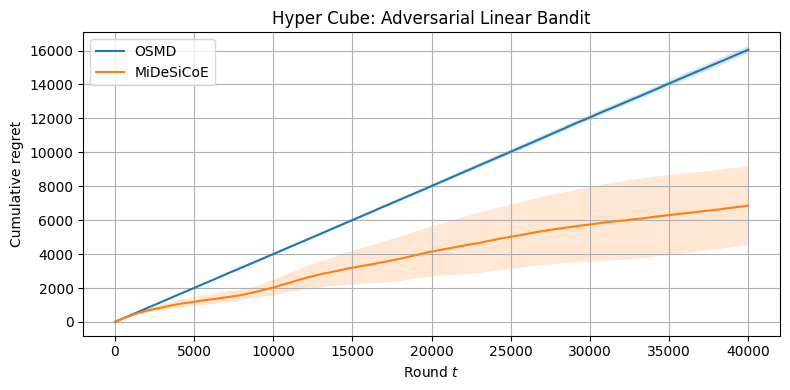

[    1  4000  8000 12000 16000 20000 24000 28000 32000 36000 40000]
[2.240000e+00 1.613320e+03 3.203730e+03 4.806430e+03 6.410200e+03
 8.015810e+03 9.628580e+03 1.125648e+04 1.286005e+04 1.446231e+04
 1.604911e+04]
[2.37000e+00 1.04988e+03 1.59481e+03 2.58494e+03 3.36908e+03 4.15171e+03
 4.85043e+03 5.49728e+03 5.97053e+03 6.40786e+03 6.85578e+03]


In [6]:
# ----------------------------- demo -----------------------------
d, s, T, runs = 400, 5, 40000, 20
compare_with_std(d, s, T, runs)